# 01 — Probability Basics
**Week 2 | Mathematical Foundations for RL**

By the end of this notebook you will:
- Simulate discrete and continuous random variables
- Compute empirical mean, variance, and compare to theoretical values
- Visualise distributions and understand their shape

These are the building blocks for understanding stochastic rewards in RL.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## 1. Dice Simulation
A fair 6-sided die — simplest discrete random variable.

Empirical mean:     3.4999  (theoretical: 3.5000)
Empirical variance: 2.9194  (theoretical: 2.9167)


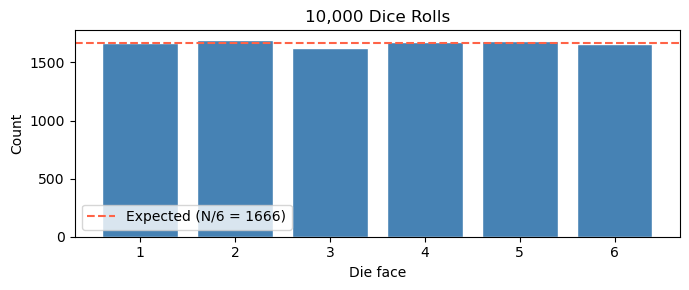

In [2]:
# Simulate N dice rolls
N = 10_000
rolls = np.random.randint(1, 7, size=N)

# Theoretical values
theoretical_mean = 3.5
theoretical_var  = 35/12  # (b-a+1)^2 - 1) / 12 for uniform discrete

print(f"Empirical mean:     {rolls.mean():.4f}  (theoretical: {theoretical_mean:.4f})")
print(f"Empirical variance: {rolls.var():.4f}  (theoretical: {theoretical_var:.4f})")

plt.figure(figsize=(7, 3))
counts, _, bars = plt.hist(rolls, bins=np.arange(0.5, 7.5, 1), edgecolor='white', color='steelblue', rwidth=0.8)
plt.axhline(N/6, color='tomato', linestyle='--', label=f'Expected (N/6 = {N//6})')
plt.xlabel('Die face'); plt.ylabel('Count'); plt.title('10,000 Dice Rolls')
plt.xticks(range(1,7)); plt.legend(); plt.tight_layout(); plt.show()

## 2. Continuous Distribution — Normal
Many RL reward signals are approximately Gaussian.

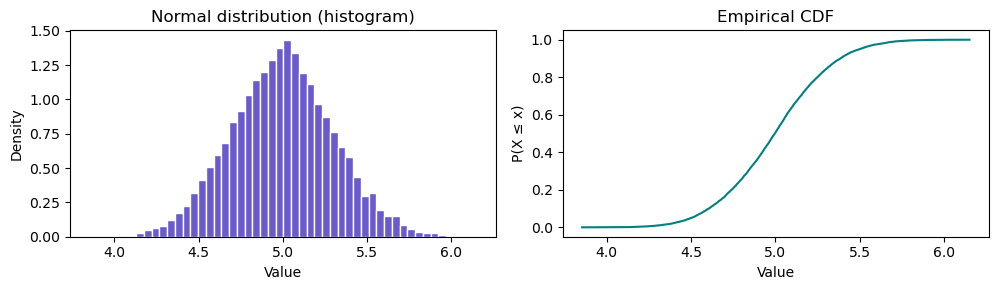

Mean: 4.996 (true: 5.0)
Std:  0.302  (true: 0.3)


In [8]:
mu, sigma = 5.0, 0.3
samples = np.random.normal(mu, sigma, size=N)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(samples, bins=50, color='slateblue', edgecolor='white', density=True)
axes[0].set_title('Normal distribution (histogram)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')

# Empirical CDF
sorted_s = np.sort(samples)
cdf = np.arange(1, N+1) / N
axes[1].plot(sorted_s, cdf, color='teal', linewidth=1.5)
axes[1].set_title('Empirical CDF')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('P(X ≤ x)')
plt.tight_layout(); plt.show()

print(f"Mean: {samples.mean():.3f} (true: {mu})")
print(f"Std:  {samples.std():.3f}  (true: {sigma})")

## 3. Expectation and Variance — Intuition
Expectation = centre of mass of the distribution.  
Variance = average squared distance from the mean (spread).

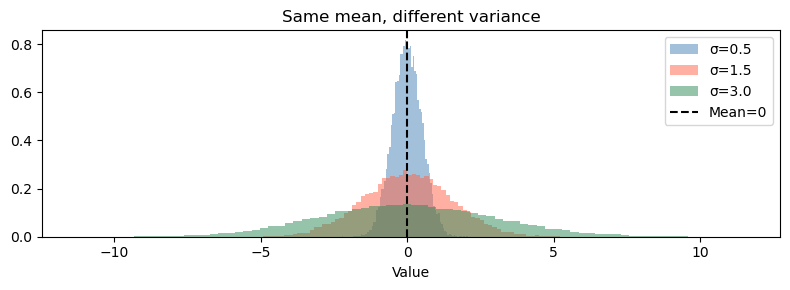

In [4]:
# Compare two distributions with same mean but different variance
fig, ax = plt.subplots(figsize=(8, 3))
for sigma_, color_, label_ in [(0.5,'steelblue','σ=0.5'), (1.5,'tomato','σ=1.5'), (3.0,'seagreen','σ=3.0')]:
    s = np.random.normal(0, sigma_, 20_000)
    ax.hist(s, bins=80, alpha=0.5, density=True, color=color_, label=label_)
ax.axvline(0, color='black', linestyle='--', label='Mean=0')
ax.set_title('Same mean, different variance'); ax.legend(); ax.set_xlabel('Value')
plt.tight_layout(); plt.show()

## 4. The Law of Large Numbers
As we collect more samples, the empirical mean converges to E[X].  
This is why RL agents improve with experience.

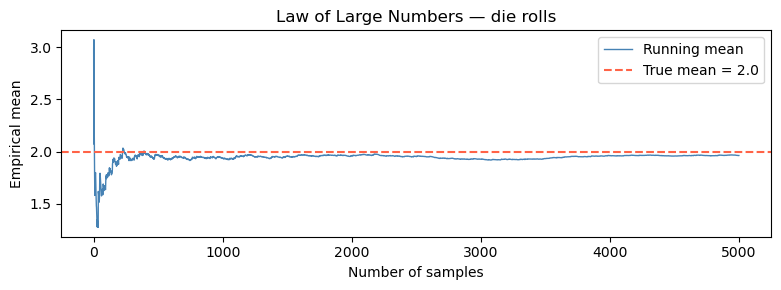

In [9]:
true_mean = 2.0
rolls_seq = np.random.exponential(scale=2.0, size=5000)
running_mean = np.cumsum(rolls_seq) / np.arange(1, 5001)

plt.figure(figsize=(8, 3))
plt.plot(running_mean, color='steelblue', linewidth=1, label='Running mean')
plt.axhline(true_mean, color='tomato', linestyle='--', label=f'True mean = {true_mean}')
plt.xlabel('Number of samples'); plt.ylabel('Empirical mean')
plt.title('Law of Large Numbers — die rolls')
plt.legend(); plt.tight_layout(); plt.show()

## ✅ Exercise
1. Change `mu` and `sigma` in section 2. What happens to the histogram shape?
2. In section 4, replace dice rolls with samples from an exponential distribution (`np.random.exponential`). Does LLN still hold?
3. **Challenge**: simulate 1000 coin flips (0/1). Plot the running fraction of heads. What does it converge to?

Ans 1) 
mu,	sigma	=	0.0,	1.5				
mu,	sigma	=	5.0,	4.0				
mu,	sigma	=	5.0,	0.3				
Changing	mu	slides	the	bell	curve	left/right	without
changing	its	shape.	Increasing	sigma	flattens	and	widens	it;	decreasing
makes	it	tall	and	narrow.	The	CDF	gets	steeper	as	sigma	shrinks.

Ans 2) Yes,	LLN	still	holds.	Convergence	is	noisier	early	on
(exponential	is	skewed,	occasional	large	values	yank	the	running
mean	up),	but	it	settles	at	2.0.

Ans3) Below is the code to simulate the law of large numbers for a biased coin with probability of heads = 0.7

Obs - 	Converges	to	0.5.	Wild	swings	in	the	first	~50	flips,	then
hugs	0.5.

C:\Users\arinu\AppData\Local\Temp\ipykernel_19284\1359442985.py:9: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.title('LLN	—	Coin	Flips');	plt.legend();	plt.tight_layout();
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


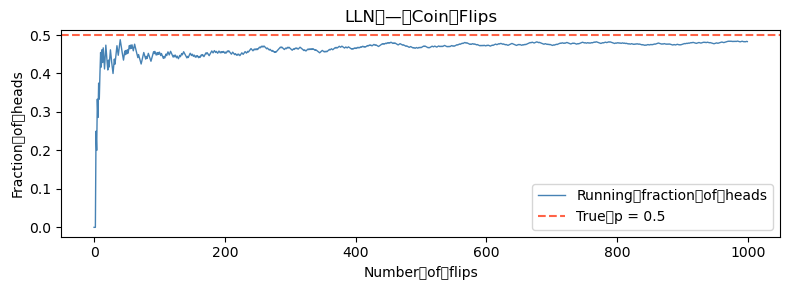

Final	fraction	after	1000	flips:	0.4830


In [12]:
flips	=	np.random.randint(0,	2,	size=1000)										
#	0	=	tails,	1	=	heads
running_frac	=	np.cumsum(flips)	/	np.arange(1,	1001)
plt.figure(figsize=(8,	3))
plt.plot(running_frac,	color='steelblue',	linewidth=1,	
label='Running	fraction	of	heads')
plt.axhline(0.5,	color='tomato',	linestyle='--',	label='True	p = 0.5')
plt.xlabel('Number	of	flips');	plt.ylabel('Fraction	of	heads')
plt.title('LLN	—	Coin	Flips');	plt.legend();	plt.tight_layout();	
plt.show()
print(f"Final	fraction	after	1000	flips:	{running_frac[-1]:.4f}")